# 02 — Exploratory Data Analysis
Distributions, outliers, and initial hypotheses.

**Input:** `data/processed/merged_data.csv`
**Output:** Charts saved to `charts/`

In [1]:
import sys
sys.path.append('..')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import MERGED_FILE, PALETTE
from src.utils import setup_plotting, save_chart, print_section
setup_plotting()
pd.set_option('display.max_columns', None)

## 1. Load merged data

In [2]:
df = pd.read_csv(MERGED_FILE)
df['date'] = pd.to_datetime(df['date'])
print(f'Shape       : {df.shape}')
print(f'Date range  : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Fear trades : {(df["Classification"]=="Fear").sum():,}')
print(f'Greed trades: {(df["Classification"]=="Greed").sum():,}')
df.describe()

Shape       : (184263, 18)
Date range  : 2023-03-28 to 2025-02-19
Fear trades : 141,012
Greed trades: 43,251


,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,date
count,184263.000000,1.842630e+05,1.842630e+05,1.842630e+05,184263.000000,1.842630e+05,184263.000000,1.842630e+05,1.842630e+05,184263
mean,9624.179560,4.588772e+03,4.780733e+03,1.634172e+04,55.492690,6.690028e+10,1.003504,5.627655e+14,1.735951e+12,2025-01-03 07:20:19.420068608
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,2023-03-28 00:00:00
25%,5.024600,3.650000e+00,1.875300e+02,-1.189096e+02,0.000000,5.728456e+10,0.015936,2.810000e+14,1.730000e+12,2024-10-27 00:00:00
50%,17.770000,3.400000e+01,5.927400e+02,3.701700e+02,0.000000,7.247926e+10,0.087527,5.620000e+14,1.740000e+12,2025-02-19 00:00:00
75%,28.920000,1.803000e+02,2.032705e+03,1.264308e+04,6.602400,7.931359e+10,0.387603,8.460000e+14,1.740000e+12,2025-02-19 00:00:00
max,109004.000000,1.582244e+07,3.509753e+06,3.050948e+07,135329.090100,8.736651e+10,539.021456,1.130000e+15,1.740000e+12,2025-02-19 00:00:00
std,27106.266497,1.105144e+05,2.690428e+04,3.938825e+05,937.857954,1.807788e+10,5.152379,3.257472e+14,7.833952e+09,NaN


## 2. Sentiment distribution

Chart saved: /app/charts/01_sentiment_distribution.png


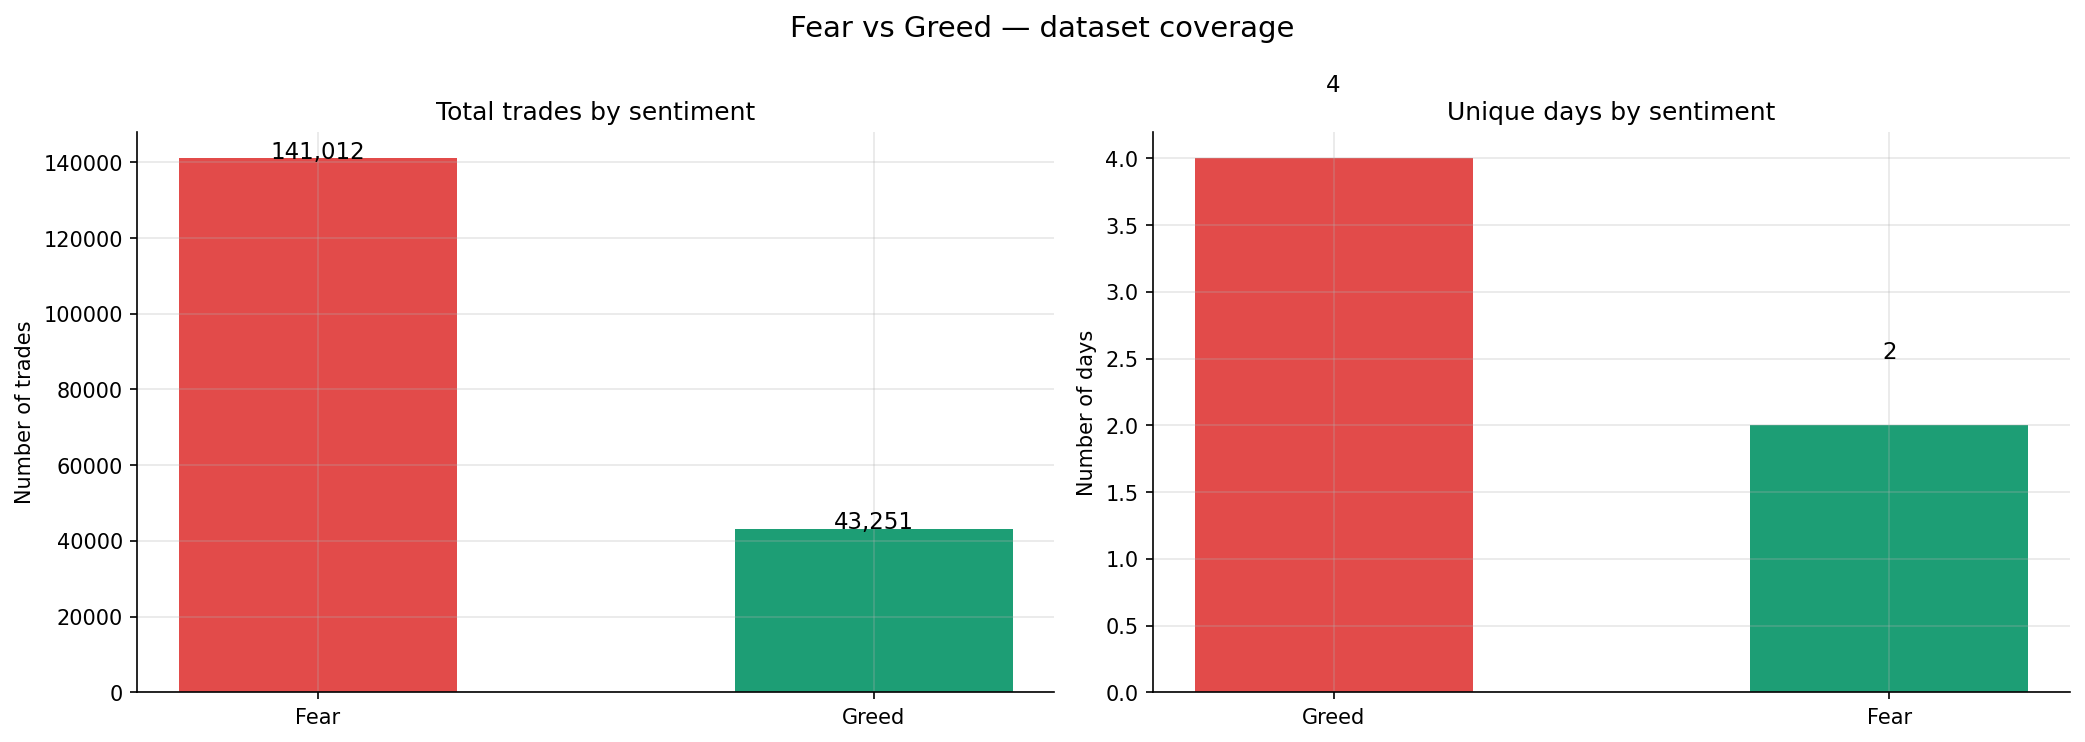

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Classification'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[PALETTE['Fear'], PALETTE['Greed']], width=0.5)
axes[0].set_title('Total trades by sentiment')
axes[0].set_ylabel('Number of trades')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontsize=11)

day_counts = df.groupby('date')['Classification'].first().value_counts()
axes[1].bar(day_counts.index, day_counts.values,
            color=[PALETTE['Fear'], PALETTE['Greed']], width=0.5)
axes[1].set_title('Unique days by sentiment')
axes[1].set_ylabel('Number of days')
for i, (idx, val) in enumerate(day_counts.items()):
    axes[1].text(i, val + 0.5, str(val), ha='center', fontsize=11)

plt.suptitle('Fear vs Greed — dataset coverage', fontsize=14)
plt.tight_layout()
save_chart(fig, '01_sentiment_distribution.png')
plt.show()

## 3. Closed PnL distribution

Chart saved: /app/charts/02_pnl_distribution.png


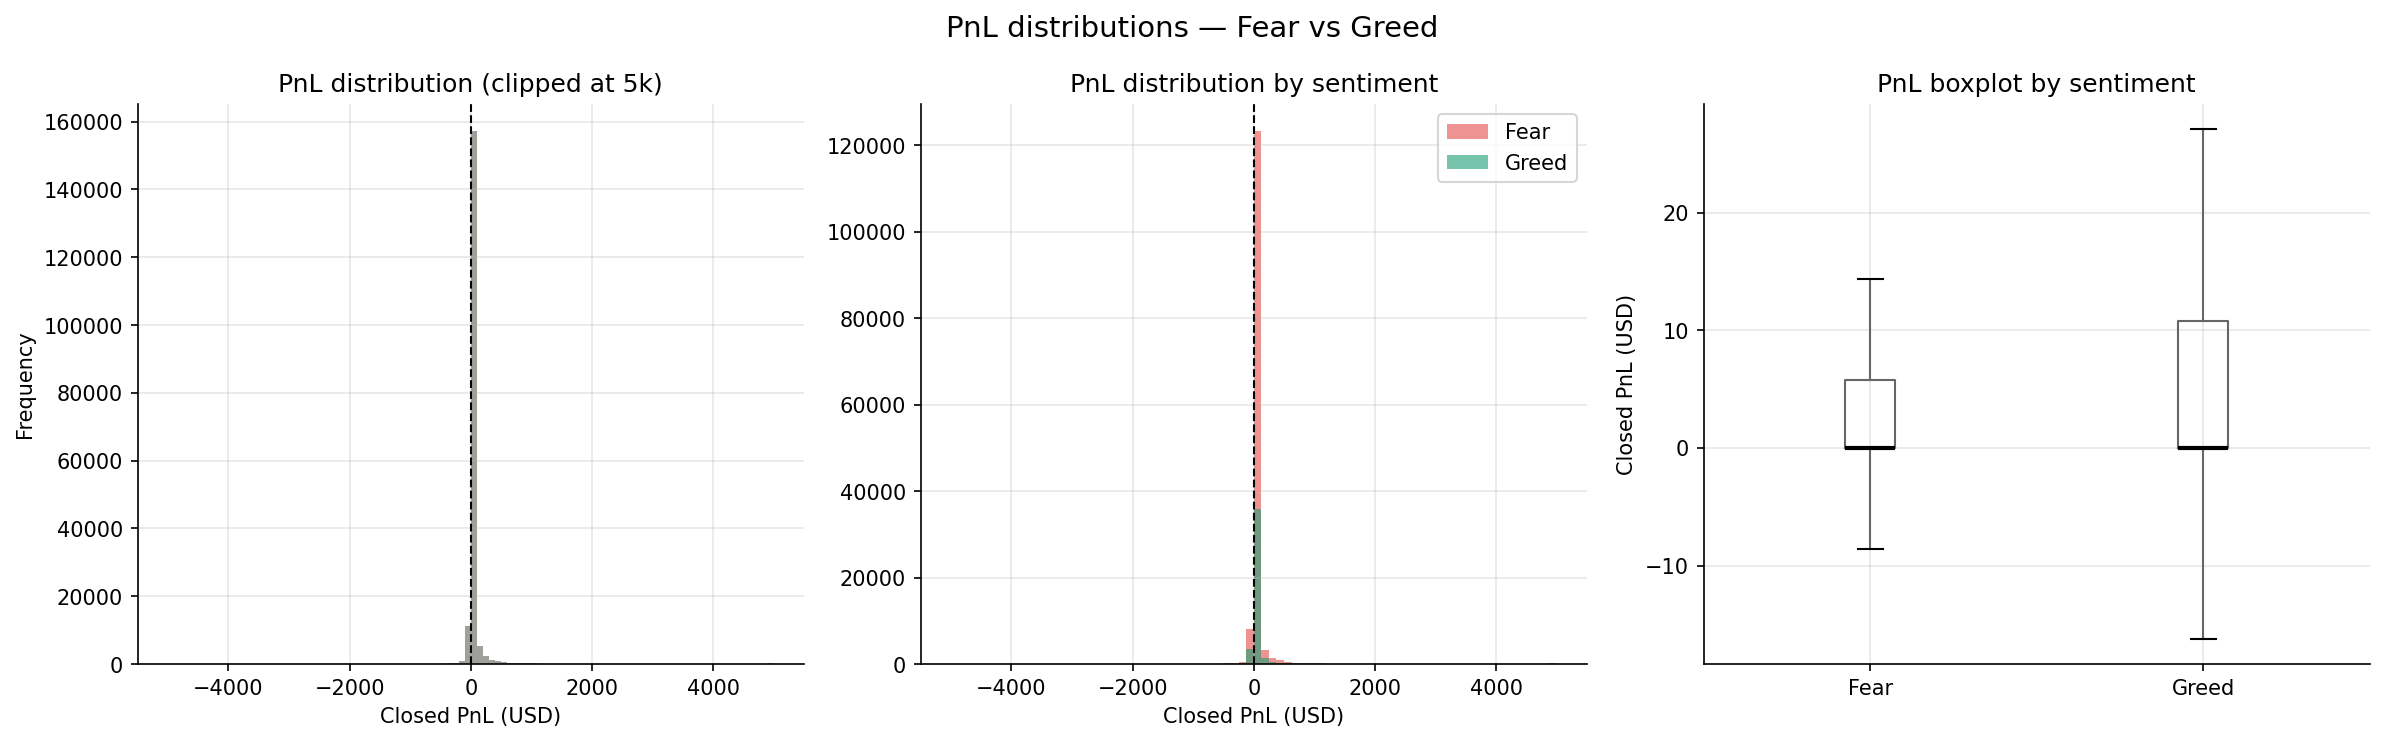

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

clipped = df['Closed PnL'].clip(-5000, 5000)
axes[0].hist(clipped, bins=100, color=PALETTE['neutral'], edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('PnL distribution (clipped at 5k)')
axes[0].set_xlabel('Closed PnL (USD)')
axes[0].set_ylabel('Frequency')

for label, color in [('Fear', PALETTE['Fear']), ('Greed', PALETTE['Greed'])]:
    subset = df[df['Classification'] == label]['Closed PnL'].clip(-5000, 5000)
    axes[1].hist(subset, bins=80, alpha=0.6, label=label, color=color, edgecolor='none')
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('PnL distribution by sentiment')
axes[1].set_xlabel('Closed PnL (USD)')
axes[1].legend()

df.boxplot(column='Closed PnL', by='Classification', ax=axes[2],
           showfliers=False,
           medianprops=dict(color='black', linewidth=2))
axes[2].set_title('PnL boxplot by sentiment')
axes[2].set_xlabel('')
axes[2].set_ylabel('Closed PnL (USD)')
plt.suptitle('')

plt.suptitle('PnL distributions — Fear vs Greed', fontsize=14)
plt.tight_layout()
save_chart(fig, '02_pnl_distribution.png')
plt.show()

## 4. Trade size (USD) distribution

Chart saved: /app/charts/03_trade_size.png


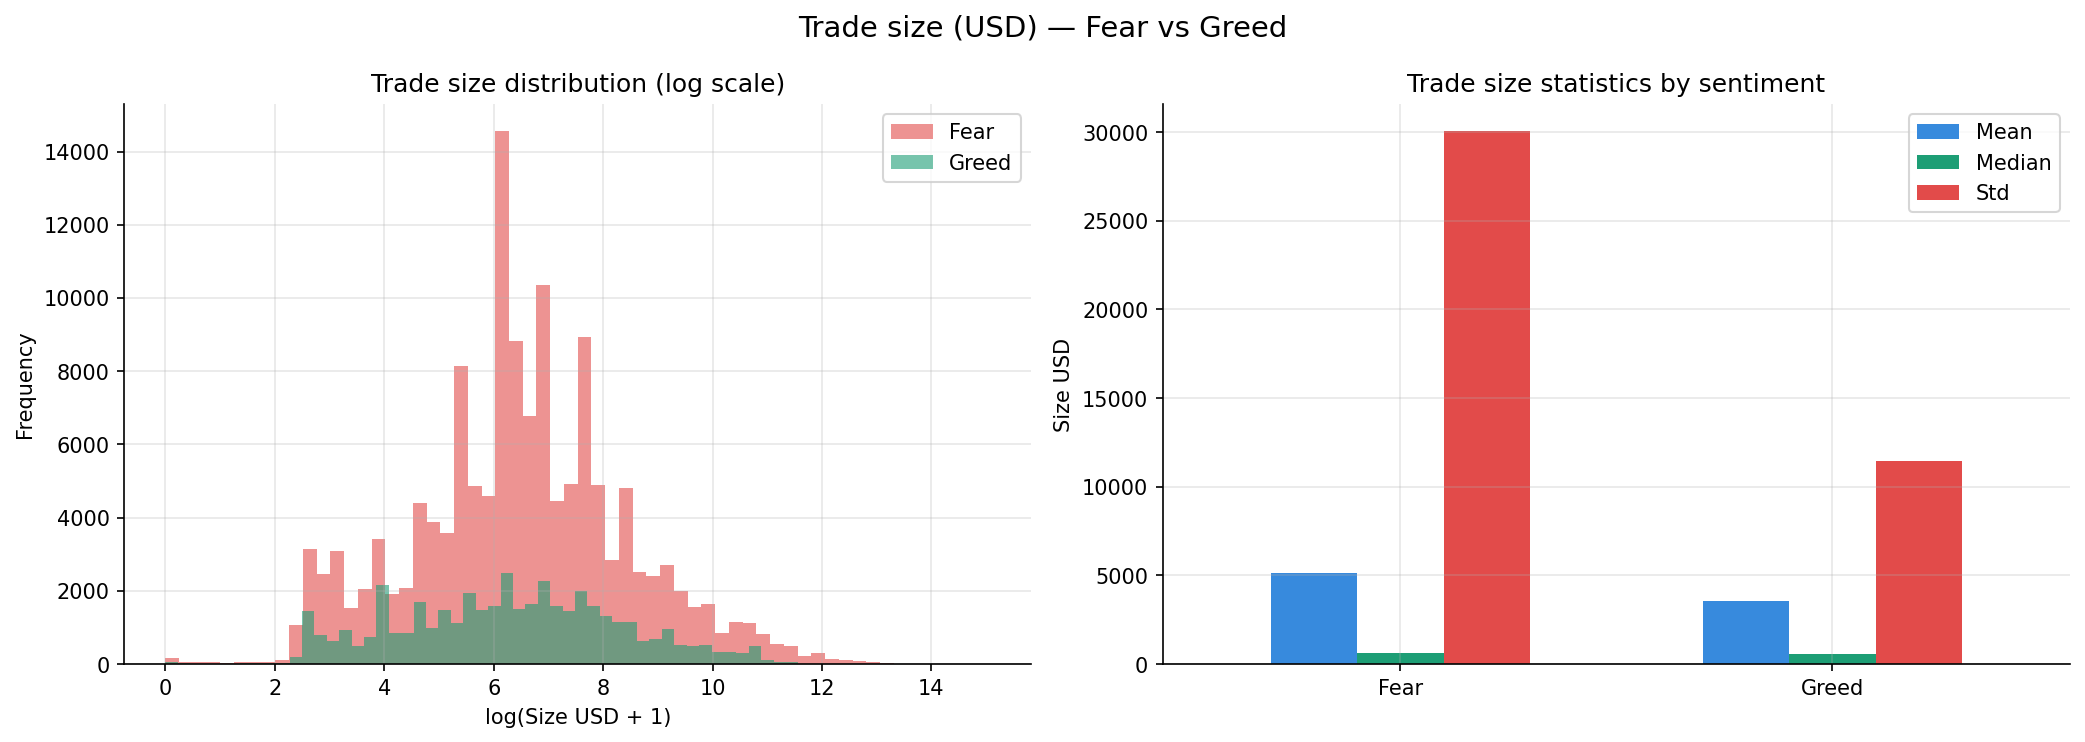

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('Fear', PALETTE['Fear']), ('Greed', PALETTE['Greed'])]:
    subset = df[df['Classification'] == label]['Size USD']
    axes[0].hist(np.log1p(subset.clip(lower=0)), bins=60,
                 alpha=0.6, label=label, color=color, edgecolor='none')
axes[0].set_title('Trade size distribution (log scale)')
axes[0].set_xlabel('log(Size USD + 1)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

size_stats = df.groupby('Classification')['Size USD'].describe()[['mean','50%','std']]
size_stats.columns = ['Mean', 'Median', 'Std']
size_stats.plot(kind='bar', ax=axes[1], width=0.6, rot=0,
                color=['#378ADD','#1D9E75','#E24B4A'])
axes[1].set_title('Trade size statistics by sentiment')
axes[1].set_xlabel('')
axes[1].set_ylabel('Size USD')
axes[1].legend()

plt.suptitle('Trade size (USD) — Fear vs Greed', fontsize=14)
plt.tight_layout()
save_chart(fig, '03_trade_size.png')
plt.show()

## 5. Long vs Short breakdown

Side values  : ['BUY' 'SELL']
Direction values: ['Buy' 'Sell' 'Open Long' 'Close Long' 'Spot Dust Conversion' 'Open Short'
 'Close Short' 'Long > Short' 'Short > Long' 'Auto-Deleveraging'
 'Settlement']
Chart saved: /app/charts/04_long_short_breakdown.png


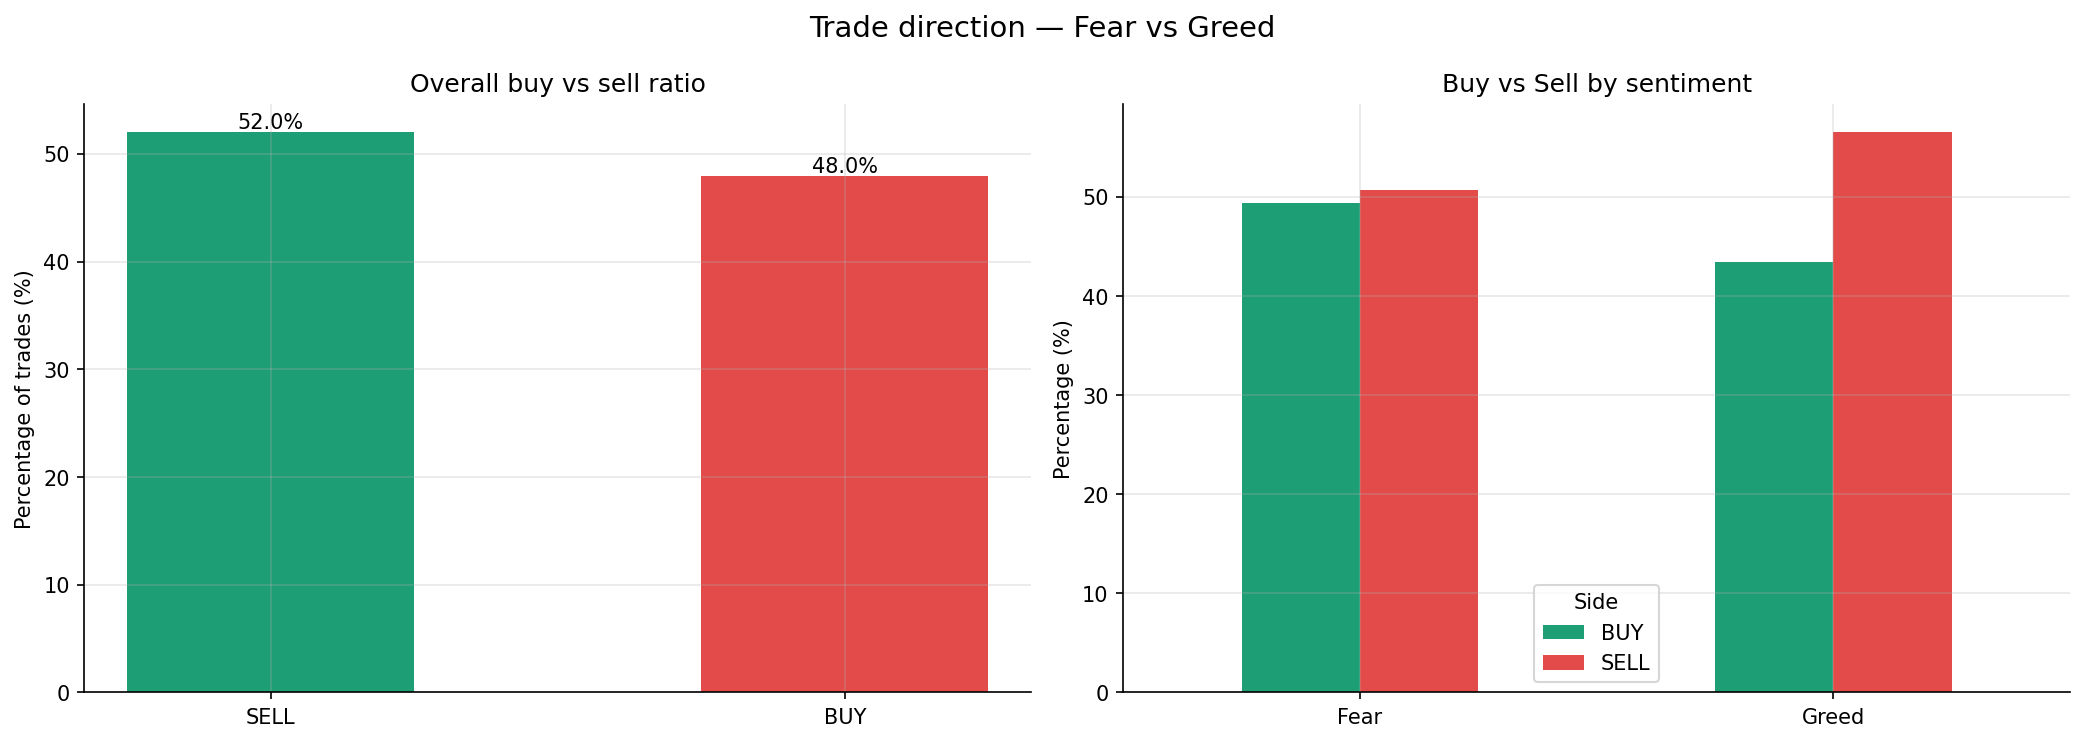

In [6]:
print('Side values  :', df['Side'].unique())
print('Direction values:', df['Direction'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

side_overall = df['Side'].value_counts(normalize=True) * 100
axes[0].bar(side_overall.index, side_overall.values,
            color=[PALETTE['Greed'], PALETTE['Fear']], width=0.5)
axes[0].set_title('Overall buy vs sell ratio')
axes[0].set_ylabel('Percentage of trades (%)')
for i, (idx, val) in enumerate(side_overall.items()):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center')

side_by_sent = df.groupby(['Classification','Side']).size().unstack(fill_value=0)
side_by_sent_pct = side_by_sent.div(side_by_sent.sum(axis=1), axis=0) * 100
side_by_sent_pct.plot(kind='bar', ax=axes[1], width=0.5, rot=0,
                      color=[PALETTE['Greed'], PALETTE['Fear']])
axes[1].set_title('Buy vs Sell by sentiment')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].legend(title='Side')

plt.suptitle('Trade direction — Fear vs Greed', fontsize=14)
plt.tight_layout()
save_chart(fig, '04_long_short_breakdown.png')
plt.show()

## 6. Fee distribution

Chart saved: /app/charts/05_fee_distribution.png


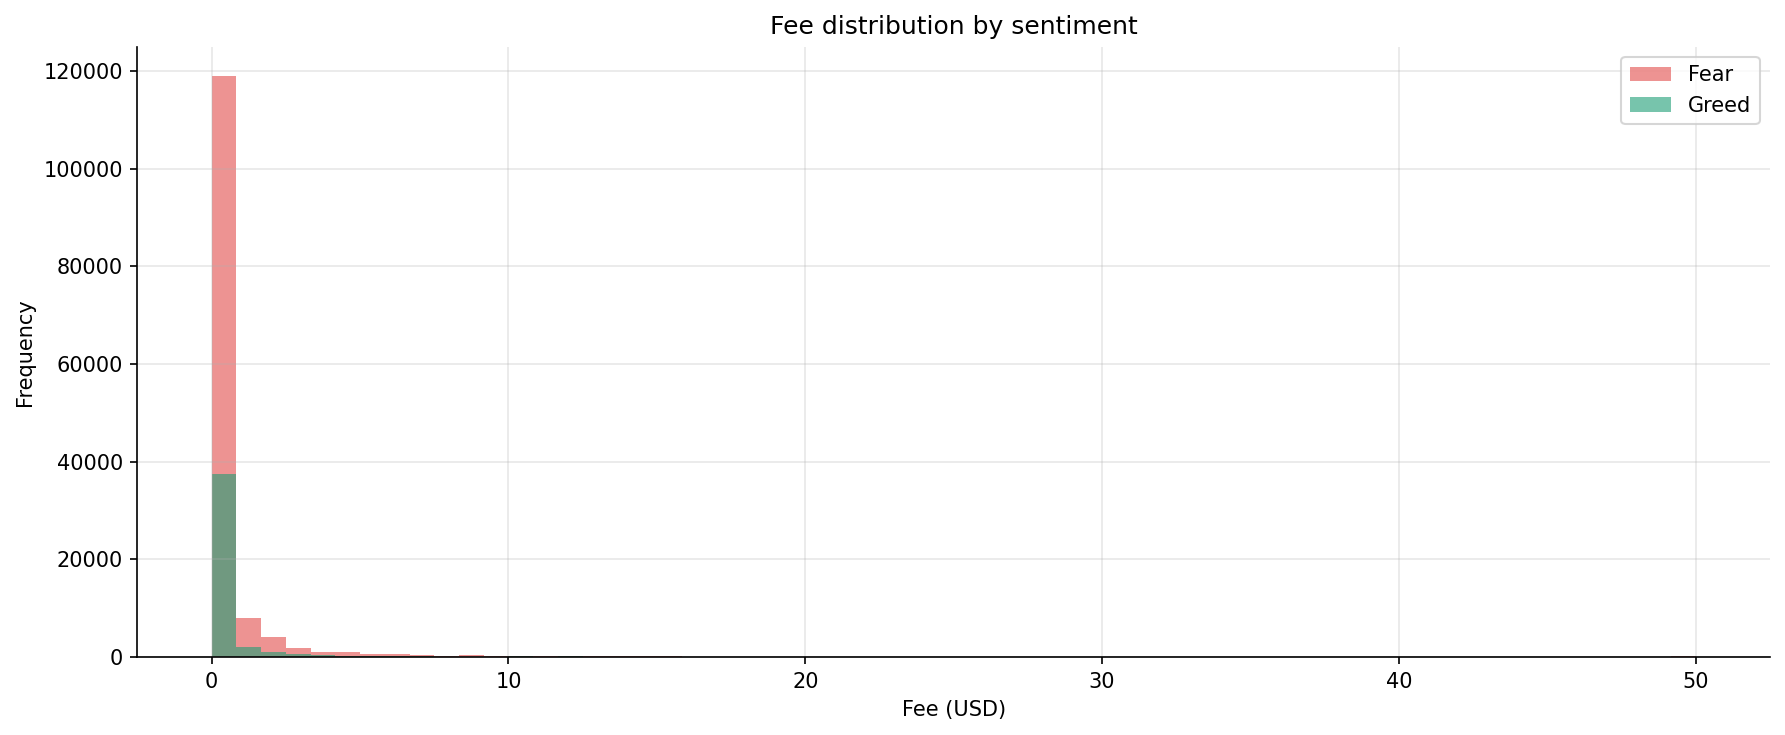

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, color in [('Fear', PALETTE['Fear']), ('Greed', PALETTE['Greed'])]:
    subset = df[df['Classification'] == label]['Fee'].clip(0, 50)
    ax.hist(subset, bins=60, alpha=0.6, label=label, color=color, edgecolor='none')
ax.set_title('Fee distribution by sentiment')
ax.set_xlabel('Fee (USD)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
save_chart(fig, '05_fee_distribution.png')
plt.show()

## 7. Summary statistics by sentiment

In [8]:
summary = df.groupby('Classification').agg(
    total_trades  = ('Closed PnL', 'count'),
    mean_pnl      = ('Closed PnL', 'mean'),
    median_pnl    = ('Closed PnL', 'median'),
    win_rate      = ('Closed PnL', lambda x: (x > 0).mean()),
    mean_size_usd = ('Size USD',   'mean'),
    mean_fee      = ('Fee',        'mean'),
).round(4)
print_section('EDA SUMMARY')
print(summary.T.to_string())


  EDA SUMMARY
Classification         Fear       Greed
total_trades    141012.0000  43251.0000
mean_pnl            48.6389     77.8382
median_pnl           0.0000      0.0000
win_rate             0.4102      0.4535
mean_size_usd     5148.5102   3581.6615
mean_fee             1.0904      0.7201
